# Разработка A/B-тестирования и анализ результатов
Автор: Ельцова Анастасия

---

Компания разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В приложении компании существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Необходимо рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

---

## Описание данных

Данные находятся в трех таблицах:
- `sessions_project_history` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23.
- `sessions_project_test_part` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.
- `sessions_project_test` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.

У таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history`, `sessions_project_test`, `sessions_project_test_part`:
- `user_id` — идентификатор пользователя
- `session_id` — идентификатор сессии в приложении
- `session_date` — дата сессии
- `session_start_ts` — дата и время начала сессии
- `install_date` — дата установки приложения
- `session_number` — порядковый номер сессии для конкретного пользователя
- `registration_flag` — является ли пользователь зарегистрированным
- `page_counter` — количество просмотренных страниц во время сессии
- `region` — регион пользователя
- `device` — тип устройства пользователя
- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет)

---

## Что нужно сделать
Рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

---
### Цель эксперимента

Провести A/B-тестирование нового алгоритма рекомендаций в развлекательном приложении с функцией "бесконечной" ленты для оценки его влияния на пользовательское вовлечение. 

---

Для этого изучим исторические данные (до проведения А/В-теста), рассчитаем необходимый размер выборки и длительность проведения А/В-теста. Проведем мониторинг А/В-теста в первый день эксперимента, чтобы проверить корректное распределение данных, исключить пересечение пользователей в тестовой и контрольной группах, оценим равномерность распределения данных в группах по типам устройств и регионам.

---

#### Ключевая метрика

Доля успешных сессий (просмотр 4+ страниц за сессию)

#### Ожидаемый эффект

Увеличение количества просмотренных сраниц во время сессии, т.к. увеличение глубины просмотра напрямую влияет на вовлеченность и монетизацию.

#### Необходимо проверить следующие гипотезы:

**Нулевая гипотеза (H₀)**: Новый алгоритм рекомендаций не оказывает статистически значимого влияния на долю успешных сессий.

**Альтернативная гипотеза (H₁)**: Новый алгоритм рекомендаций увеличивает долю успешных сессий.

В группу А были отнесены пользователи, которые видели старый алгоритм рекомендаций, в группу B - пользователи, которые видели новый алгоритм рекомендаций.

---

### Содержимое проекта

1. Работа с историческими данными (EDA)
2. Подготовка к тесту
3. Мониторинг А/В-теста
4. Проверка результатов A/B-теста
5. Вывод по результатам A/B-эксперимента

### 1. Работа с историческими данными (EDA)

---
**Загрузка исторических данных**

Сначала поработаем с историческими данными приложения:
- Импортируем необходимые библиотеки
- Считаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history`.

Выведем на экран первые пять строк полученного датафрейма.

---

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Считаем и сохраним датафрейм с историческими данными о сессиях пользователей

sessions_history = pd.read_csv("https://code._____.csv")
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


---
**Знакомимся с данными**

- Для каждого уникального пользователя `user_id` расcчитаем количество уникальных сессий `session_id`
- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий
- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

---

In [3]:
# Рассчитаем количество уникальных сессий для каждого уникального пользователя
sessions_history.groupby("user_id", as_index=False)["session_id"].nunique().sort_values(
    by="session_id", ascending=False
)

,user_id,session_id
8948,10E0DEFC1ABDBBE0,10
55627,6A73CB5566BB494D,10
72346,8A60431A825D035B,9
109383,D11541BAC141FB94,9
47956,5BCFE7C4DCC148E9,9
...,...,...
15859,1DF13BB1953B3497,1
51449,628502A3CE7E0A3C,1
15853,1DEEF40DEFBD0C65,1
89905,AC08479B7472C628,1


In [4]:
# Выводим данные из таблицы sessions_history для пользователя с наибольшим количеством сессий
sessions_history[
    sessions_history["user_id"]
    == sessions_history.groupby("user_id")["session_id"].nunique().idxmax()
]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


---
**Анализ числа регистраций**

Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования.
- Агрегируем исторические данные и расчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты будем считать, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.
- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразим их на одном графике.
- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

---

In [5]:
# Рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения
daily_stats = (
    sessions_history.groupby("session_date")
    .agg(unique_users=("user_id", "nunique"), reg_users=("registration_flag", "sum"))
    .reset_index()
)
daily_stats

,session_date,unique_users,reg_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840
5,2025-08-16,12205,916
6,2025-08-17,11200,833
7,2025-08-18,10839,860
8,2025-08-19,12118,831
9,2025-08-20,13514,1008


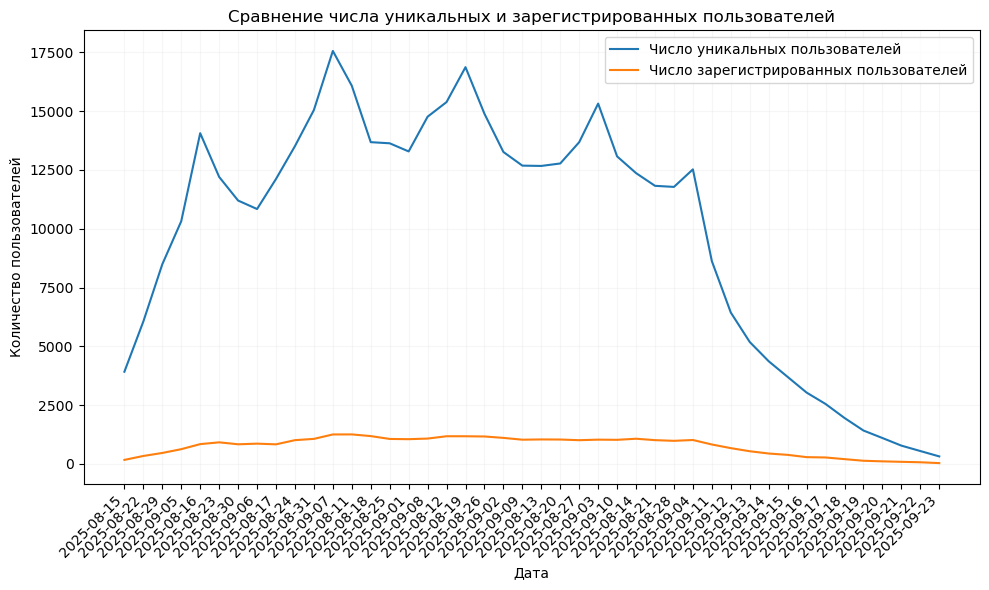

In [6]:
# Построим линейные графики числа пользователей и зарегитрированных пользователей по дням
date = sessions_history.session_date.unique()
unique_users = daily_stats["unique_users"]
reg_users = daily_stats["reg_users"]

plt.figure(figsize=(10, 6))
plt.plot(date, unique_users, label="Число уникальных пользователей")
plt.plot(date, reg_users, label="Число зарегистрированных пользователей")

plt.xlabel("Дата")
plt.ylabel("Количество пользователей")
plt.legend()
plt.title("Сравнение числа уникальных и зарегистрированных пользователей")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

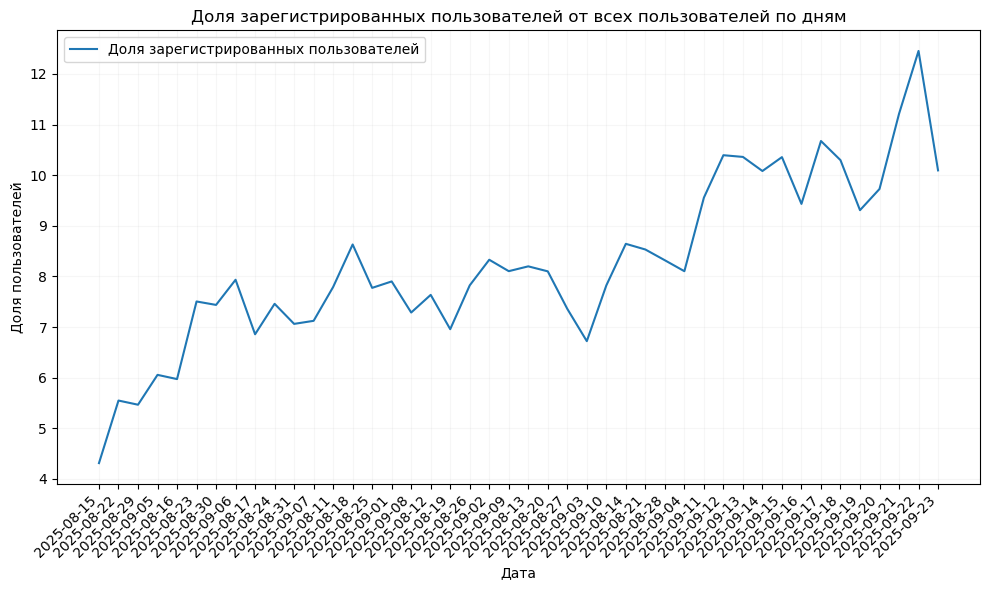

In [7]:
# График доли зарегистрированных пользователей от всех пользователей по дням
per_reg_users = reg_users / unique_users * 100

plt.figure(figsize=(10, 6))
plt.plot(date, per_reg_users, label="Доля зарегистрированных пользователей")
plt.xlabel("Дата")
plt.ylabel("Доля пользователей")
plt.legend()
plt.title("Доля зарегистрированных пользователей от всех пользователей по дням")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

---
**Анализ числа просмотренных страниц**

Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдем количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.
- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

---

In [8]:
# Посчитаем количество сессий для каждого значения количества просмотренных страниц
sessions_count = (
    sessions_history.groupby("page_counter")["session_id"].agg("count").reset_index()
)
sessions_count

,page_counter,session_id
0,1,29160
1,2,105536
2,3,166690
3,4,105569
4,5,26288
5,6,2589
6,7,92


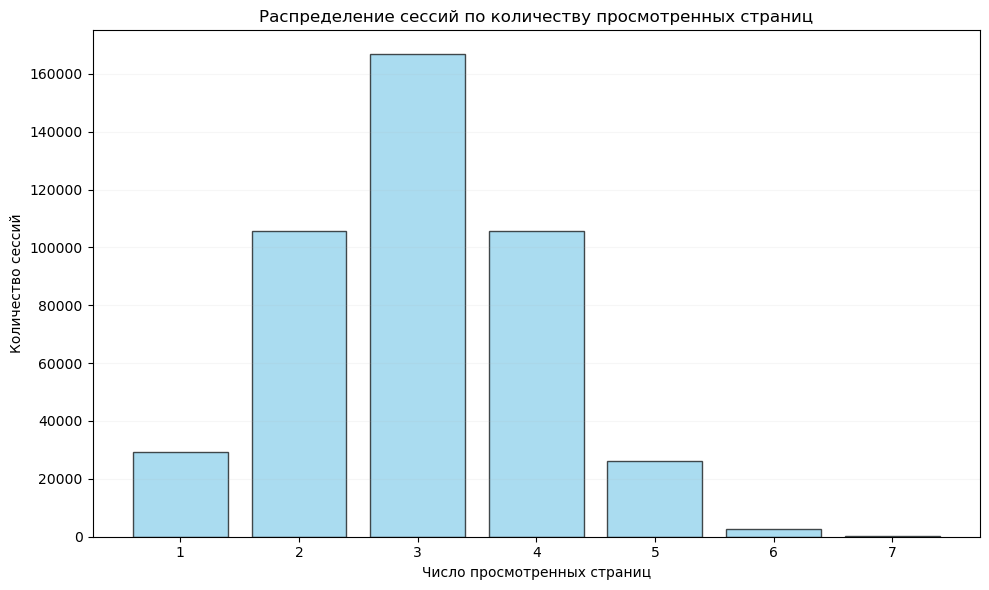

In [9]:
# Построим столбчатую диаграмму
plt.figure(figsize=(10, 6))
plt.bar(
    sessions_count["page_counter"],
    sessions_count["session_id"],
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
)

plt.xlabel("Число просмотренных страниц")
plt.ylabel("Количество сессий")
plt.title("Распределение сессий по количеству просмотренных страниц")
plt.grid(axis="y", alpha=0.1)
plt.tight_layout()
plt.show()

---
**Доля пользователей, просмотревших более четырёх страниц**

Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.
- Построим график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

---

In [10]:
# Присваиваем бинарные переменные для сессий
sessions_history["good_session"] = 0
sessions_history.loc[sessions_history["page_counter"] >= 4, "good_session"] = 1

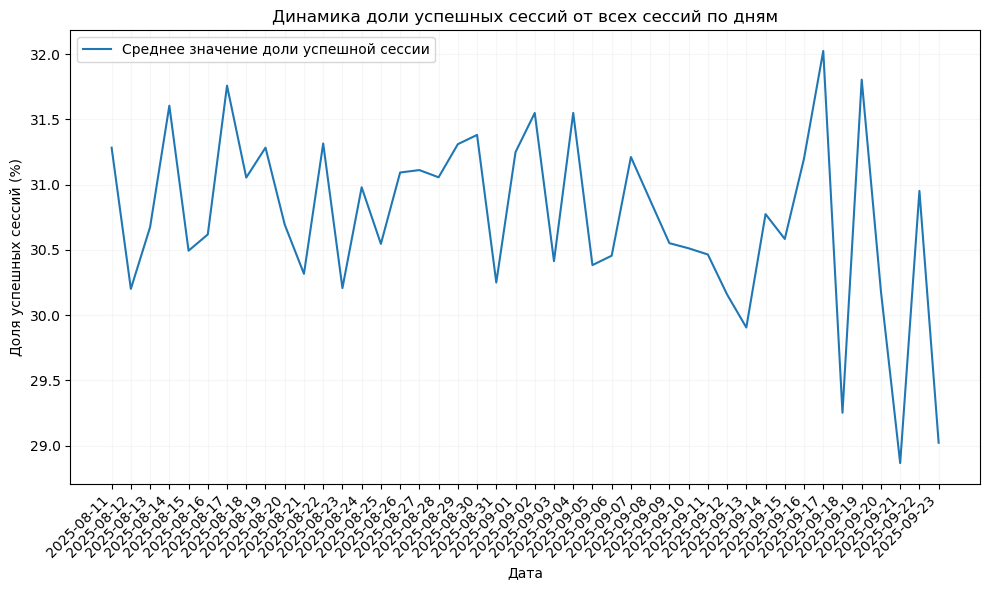

In [11]:
# Построим график со средним значением доли успешных сессий от всех сессий по дням
avg_good_session = (
    sessions_history.groupby("session_date")["good_session"].mean().reset_index()
)

plt.figure(figsize=(10, 6))
plt.plot(
    avg_good_session["session_date"],
    avg_good_session["good_session"] * 100,
    label="Среднее значение доли успешной сессии",
)
plt.xlabel("Дата")
plt.ylabel("Доля успешных сессий (%)")
plt.legend()
plt.title("Динамика доли успешных сессий от всех сессий по дням")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

---
### 2. Подготовка к тесту

- Сформулируем нулевую и альтернативную гипотезы
- Определимся с целевой метрикой
- Рассчитаем необходимый размер выборки
- Исходя из текущих значений трафика рассчитаем необходимую длительность проведения теста

---

**Формулировка нулевой и альтернативной гипотез**

Сформулируем нулевую и альтернативную гипотезы. Изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

**H₀**: Новый алгоритм не влияет на среднее количество просмотренных страниц за сессию

**H₁**: Новый алгоритм увеличивает среднее количество просмотренных страниц за сессию

---

**Расчёт размера выборки**

Рассчитаем необходимое для эксперимента количество пользователей.

Для этого установим в коде следующие параметры:
- Уровень значимости — 0.05
- Вероятность ошибки второго рода — 0.2
- Мощность теста
- Минимальный детектируемый эффект, или MDE, — 3%

При расчёте размера выборки будем использовать метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

---

In [12]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3  # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1,  # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


---
**Расчёт длительности A/B-теста**

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.
- Рассчитаем среднее количество уникальных пользователей приложения в день
- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону

---

In [13]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby("session_date")["user_id"].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(
    f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней"
)

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


---
### 3. Мониторинг А/В-теста

---

**Проверка распределения пользователей**

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.
- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`
- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения
- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. Построим визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

---

In [14]:
# Считаем и сохраним датафрейм с данными за первый день проведения А/В-теста
sessions_test_part = pd.read_csv("https://code._____.csv")
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [15]:
# Рассчитаем количество уникальных пользователей в каждой группе для одного дня наблюдения
group_counts = sessions_test_part.groupby("test_group", as_index=False)[
    ["user_id"]
].nunique()
group_counts

,test_group,user_id
0,A,1477
1,B,1466


In [16]:
# Посмотрим, в каком процентном соотношении находятся группы
round(
    100
    * sessions_test_part[sessions_test_part["test_group"] == "A"]["user_id"].nunique()
    / sessions_test_part["user_id"].nunique(),
    2,
), round(
    100
    * sessions_test_part[sessions_test_part["test_group"] == "B"]["user_id"].nunique()
    / sessions_test_part["user_id"].nunique(),
    2,
)

(50.19, 49.81)

In [17]:
# Рассчитаем процентную разницу в количестве пользователей в группах A и B
group_A = group_counts[group_counts["test_group"] == "A"]["user_id"].values[0]
group_B = group_counts[group_counts["test_group"] == "B"]["user_id"].values[0]

percentage_difference = 100 * ((group_A - group_B) / group_A)
percentage_difference

0.7447528774542992

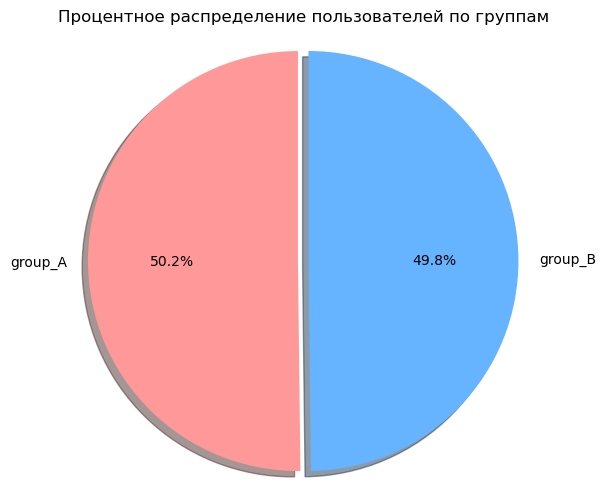

In [18]:
# Построим визуализацию, на которой будет видно возможное различие двух групп
groups = ["group_A", "group_B"]
users = [1477, 1466]

plt.figure(figsize=(6, 6))
colors = ["#ff9999", "#66b3ff"]
explode = (0.05, 0)

plt.pie(
    users,
    labels=groups,
    autopct="%1.1f%%",
    colors=colors,
    explode=explode,
    startangle=90,
    shadow=True,
)
plt.title("Процентное распределение пользователей по группам")
plt.axis("equal")
plt.show()

---
**Проверка пересечений пользователей**

Убедимся в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

---

In [19]:
# Проверим пересечение пользователей в группах А и В
group_A = group_counts[group_counts["test_group"] == "A"]["user_id"]
group_B = group_counts[group_counts["test_group"] == "B"]["user_id"]

intersection = list(set(group_A) & set(group_B))
intersection

[]

---
Пересечений нет

---

**Равномерность разделения пользователей по устройствам**

Убедимся в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:
- доля каждого типа устройства для пользователей из группы A
- доля каждого типа устройства для пользователей из группы B

In [20]:
# Считаем долю каждого типа устройства для пользователей из группы А
device_ratio_a = (
    sessions_test_part[sessions_test_part["test_group"] == "A"]
    .groupby("device")["user_id"]
    .nunique()
    .reset_index(name="unique_users")
)
total_a = device_ratio_a["unique_users"].sum()
device_ratio_a["percentage"] = round(
    (device_ratio_a["unique_users"] / total_a) * 100, 2
)
device_ratio_a = device_ratio_a.sort_values("percentage", ascending=False).reset_index(
    drop=True
)
print(
    f"Общее количество пользователей в группе А: {total_a}\n\nДолевое распределение пользователей по типам устройств в группе А \n\n{device_ratio_a}"
)

Общее количество пользователей в группе А: 1477

Долевое распределение пользователей по типам устройств в группе А 

    device  unique_users  percentage
0  Android           656       44.41
1       PC           369       24.98
2   iPhone           296       20.04
3      Mac           156       10.56


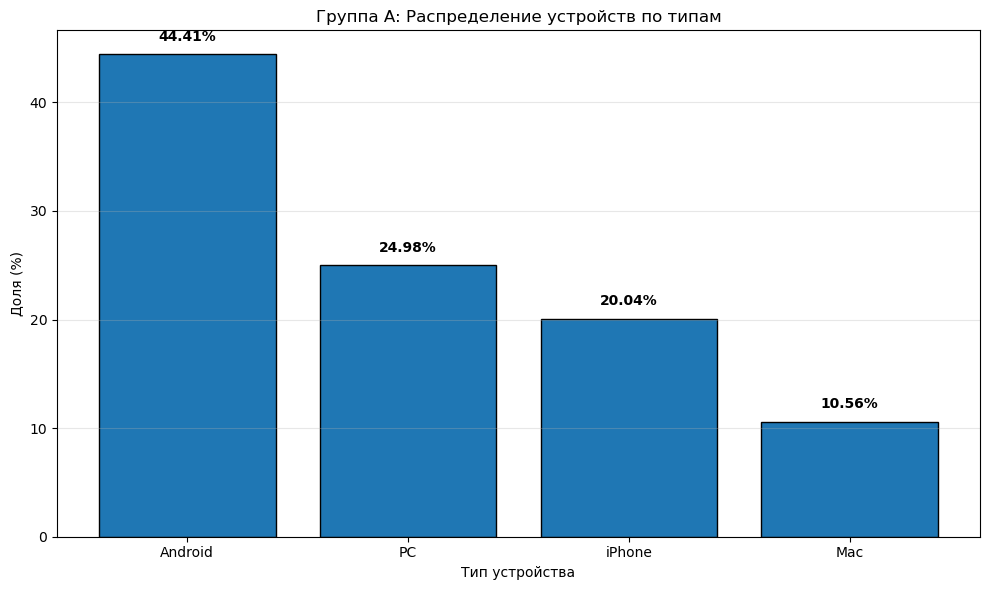

In [21]:
# Построим столбчатую даграмму для доли каждого устройства для пользователей в группе А
plt.figure(figsize=(10, 6))
bars = plt.bar(
    device_ratio_a["device"], device_ratio_a["percentage"], edgecolor="black"
)
plt.xlabel("Тип устройства")
plt.ylabel("Доля (%)")
plt.title("Группа A: Распределение устройств по типам")
plt.grid(axis="y", alpha=0.3)

for bar, percentage in zip(bars, device_ratio_a["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{percentage}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

In [22]:
# Считаем долю каждого типа устройства для пользователей в группе В
device_ratio_b = (
    sessions_test_part[sessions_test_part["test_group"] == "B"]
    .groupby("device")["user_id"]
    .nunique()
    .reset_index(name="unique_users")
)
total_b = device_ratio_b["unique_users"].sum()
device_ratio_b["percentage"] = round(
    (device_ratio_b["unique_users"] / total_b) * 100, 2
)
device_ratio_b = device_ratio_b.sort_values("percentage", ascending=False).reset_index(
    drop=True
)
print(
    f"Общее количество пользователей в группе B: {total_b}\n\nДолевое распределение пользователей по типам устройств в группе B \n\n{device_ratio_b}"
)

Общее количество пользователей в группе B: 1466

Долевое распределение пользователей по типам устройств в группе B 

    device  unique_users  percentage
0  Android           668       45.57
1       PC           381       25.99
2   iPhone           269       18.35
3      Mac           148       10.10


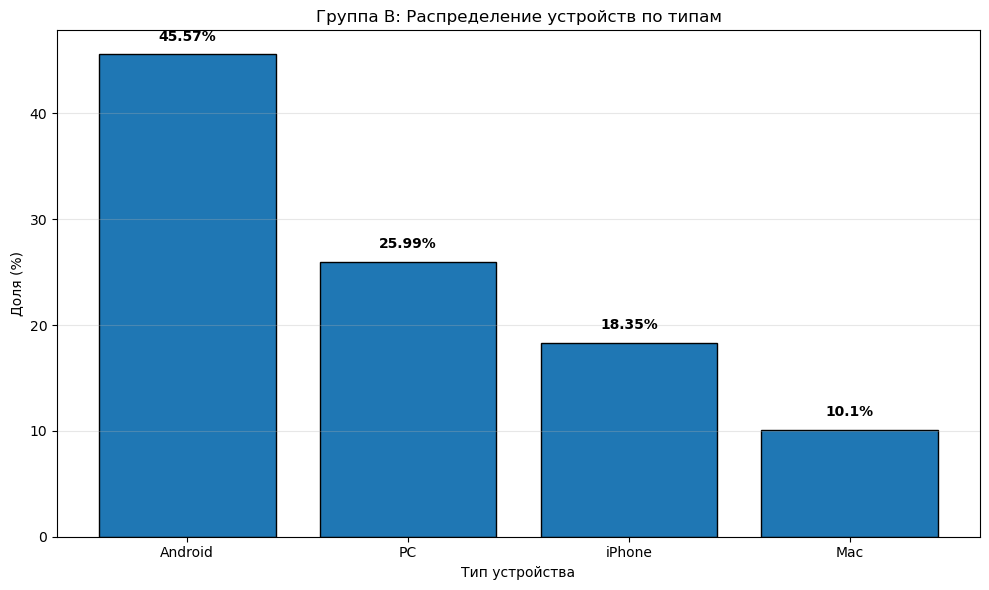

In [23]:
# Построим столбчатую даграмму для доли каждого устройства для пользователей в группе B
plt.figure(figsize=(10, 6))
bars = plt.bar(
    device_ratio_b["device"], device_ratio_b["percentage"], edgecolor="black"
)
plt.xlabel("Тип устройства")
plt.ylabel("Доля (%)")
plt.title("Группа В: Распределение устройств по типам")
plt.grid(axis="y", alpha=0.3)

for bar, percentage in zip(bars, device_ratio_b["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{percentage}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

---
**Равномерность распределения пользователей по регионам**

Убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:
- доля каждого региона для пользователей из группы A
- доля каждого региона для пользователей из группы B

In [24]:
# Считаем долю каждого региона для пользователей в группе А
region_ratio_a = (
    sessions_test_part[sessions_test_part["test_group"] == "A"]
    .groupby("region")["user_id"]
    .nunique()
    .reset_index(name="unique_users")
)
total_region_a = region_ratio_a["unique_users"].sum()
region_ratio_a["percentage"] = round(
    (region_ratio_a["unique_users"] / total_region_a) * 100, 2
)
region_ratio_a = region_ratio_a.sort_values("percentage", ascending=False).reset_index(
    drop=True
)
print(
    f"Общее количество пользователей в группе А: {total_region_a}\n\nДолевое распределение пользователей по регионам в группе А \n\n{region_ratio_a}"
)

Общее количество пользователей в группе А: 1477

Долевое распределение пользователей по регионам в группе А 

  region  unique_users  percentage
0    CIS           644       43.60
1   MENA           609       41.23
2     EU           224       15.17


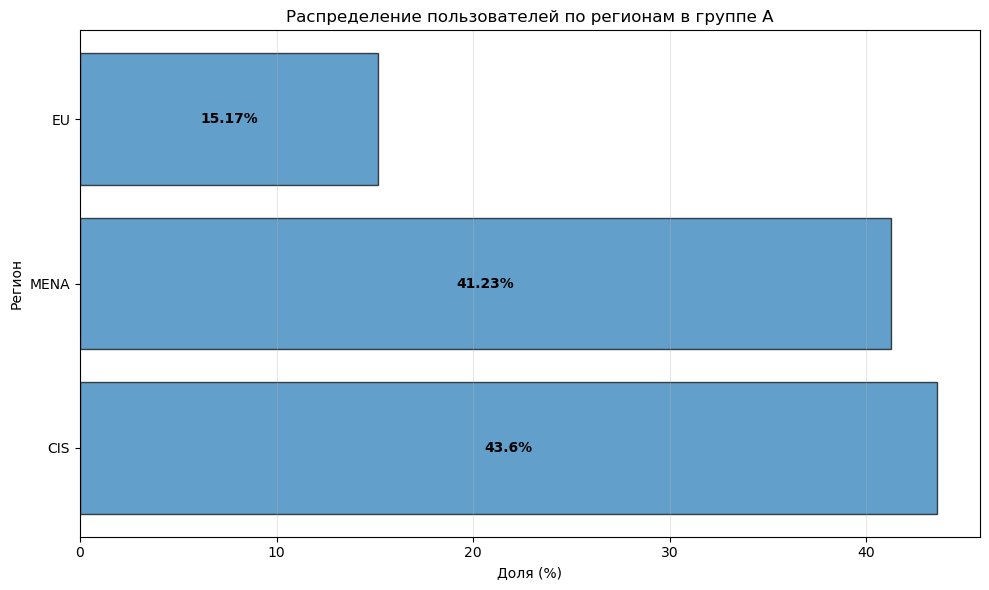

In [25]:
# Построим горизонтальную столбчатую диаграмму распределения пользователей по регионам в группе А
plt.figure(figsize=(10, 6))
bars = plt.barh(
    region_ratio_a["region"], region_ratio_a["percentage"], edgecolor="black", alpha=0.7
)

plt.xlabel("Доля (%)")
plt.ylabel("Регион")
plt.title("Распределение пользователей по регионам в группе А")
plt.grid(axis="x", alpha=0.3)

for i, (region, percentage) in enumerate(
    zip(region_ratio_a["region"], region_ratio_a["percentage"])
):
    plt.text(
        percentage / 2,
        i,
        f"{percentage}%",
        va="center",
        ha="center",
        fontweight="bold",
        color="black",
    )

plt.tight_layout()
plt.show()

In [26]:
# Считаем долю каждого региона для пользователей в группе В
region_ratio_b = (
    sessions_test_part[sessions_test_part["test_group"] == "B"]
    .groupby("region")["user_id"]
    .nunique()
    .reset_index(name="unique_users")
)
total_region_b = region_ratio_b["unique_users"].sum()
region_ratio_b["percentage"] = round(
    (region_ratio_b["unique_users"] / total_region_b) * 100, 2
)
region_ratio_b = region_ratio_b.sort_values("percentage", ascending=False).reset_index(
    drop=True
)
print(
    f"Общее количество пользователей в группе B: {total_region_b}\n\nДолевое распределение пользователей по регионам в группе B \n\n{region_ratio_b}"
)

Общее количество пользователей в группе B: 1466

Долевое распределение пользователей по регионам в группе B 

  region  unique_users  percentage
0    CIS           645        44.0
1   MENA           604        41.2
2     EU           217        14.8


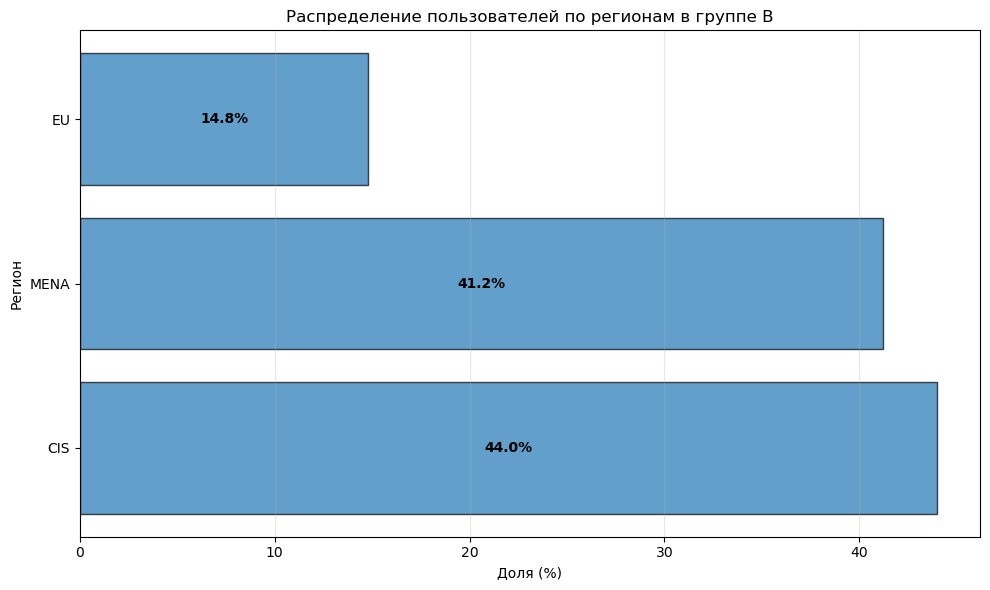

In [27]:
# Построим горизонтальную столбчатую диаграмму распределения пользователей по регионам в группе B
plt.figure(figsize=(10, 6))
bars = plt.barh(
    region_ratio_b["region"], region_ratio_b["percentage"], edgecolor="black", alpha=0.7
)

plt.xlabel("Доля (%)")
plt.ylabel("Регион")
plt.title("Распределение пользователей по регионам в группе B")
plt.grid(axis="x", alpha=0.3)

for i, (region, percentage) in enumerate(
    zip(region_ratio_b["region"], region_ratio_b["percentage"])
):
    plt.text(
        percentage / 2,
        i,
        f"{percentage}%",
        va="center",
        ha="center",
        fontweight="bold",
        color="black",
    )

plt.tight_layout()
plt.show()

---
**На основе проведенного анализа А/В-теста можно сделать следующие выводы:**

* Количество пользователей в группах А и В имеет незначительное отличие - 50,19% в группе A против 49,81% в группе B. Разница составляет менее 1%, что является допустимым для корректного проведения теста.
* Пересечения пользователей между тестовой и контрольной группами не обнаружено. Все пользователи присутствуют исключительно в одной из групп, что подтверждает независимость выборок.
* Распределение пользователей по категориальным переменным (типы устройств и регионы) сохраняет равномерность между группами. Статистически значимых различий в распределении не выявлено.

A/B-тест проводится корректно. Нарушений в процедуре рандомизации и распределения пользователей не обнаружено. Полученные результаты можно считать статистически валидными для дальнейшего анализа влияния изменений на ключевые метрики.

---

### 4. Проверка результатов A/B-теста

A/B-тест завершён, у нас есть результаты за все дни проведения эксперимента. Убедимся в корректности теста и верно интерпретируем результаты.

---

**Получение результатов теста и подсчёт основной метрики**

Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

---

In [28]:
# Считаем и сохраним датафрейм с данными за весь период проведения А/В-теста
sessions_test = pd.read_csv("https://code._____.csv"
)
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [29]:
# Присваиваем бинарные переменные для сессий
sessions_test["good_session"] = 0
sessions_test.loc[sessions_test["page_counter"] >= 4, "good_session"] = 1

---
**Проверка корректности результатов теста**

Убедимся, что тест проведён корректно и мы будем сравнивать две сопоставимые группы.

Рассчитаем количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

Проверим, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используем статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

---

In [30]:
# Рассчитаем количество уникальных сессий для каждого дня и обеих тестовых групп
unique_sessions = (
    sessions_test.groupby(["session_date", "test_group"])["session_id"]
    .nunique()
    .reset_index()
)
unique_sessions

,session_date,test_group,session_id
0,2025-10-14,A,1502
1,2025-10-14,B,1628
2,2025-10-15,A,2235
3,2025-10-15,B,2283
4,2025-10-16,A,3280
5,2025-10-16,B,3241
6,2025-10-17,A,4089
7,2025-10-17,B,4054
8,2025-10-18,A,5013
9,2025-10-18,B,5059


---
Формируем нулевую и альтернативную гипотезу:
* H₀: Количество уникальных дневных сессий в группах А и В не имеет статистически значимых различий.
* H₁: Количество уникальных дневных сессий в группах А и В статистически значимо различаются.

---

In [31]:
# формируем выборки
sample_1 = unique_sessions[unique_sessions["test_group"] == "A"]["session_id"]
sample_2 = unique_sessions[unique_sessions["test_group"] == "B"]["session_id"]

# определяем альфа
alpha = 0.05
# запускаем тест Стьюдента
results = st.ttest_ind(sample_1, sample_2)

print("p-значение:", results.pvalue)

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Нет оснований отвергать нулевую гипотезу")

p-значение: 0.938219304859116
Нет оснований отвергать нулевую гипотезу


---
**Сравнение доли успешных сессий**

Переходим к анализу ключевой метрики — доли успешных сессий.

Используя созданный на первом шаге задания столбец `good_session` рассчитаем долю успешных сессий для выборок A и B, а также разницу в этом показателе.

---

In [32]:
# Группируем по test_group и считаем метрики
group_stats = (
    sessions_test.groupby("test_group")
    .agg(total_sessions=("session_id", "count"), good_sessions=("good_session", "sum"))
    .reset_index()
)

# Считаем доли
group_stats["success_rate"] = (
    group_stats["good_sessions"] / group_stats["total_sessions"]
) * 100

# Извлекаем значения
per_good_sessions_a = group_stats[group_stats["test_group"] == "A"][
    "success_rate"
].values[0]
per_good_sessions_b = group_stats[group_stats["test_group"] == "B"][
    "success_rate"
].values[0]

# Разницы
absolute_diff = per_good_sessions_a - per_good_sessions_b
relative_diff = (absolute_diff / per_good_sessions_a) * 100

print("Результаты:")
print(group_stats)
print(f"\nАбсолютная разница: {absolute_diff:.2f}%")
print(f"Относительная разница: {relative_diff:.2f}%")

Результаты:
  test_group  total_sessions  good_sessions  success_rate
0          A           49551          15248     30.772336
1          B           50454          16059     31.828993

Абсолютная разница: -1.06%
Относительная разница: -3.43%


---
**Насколько статистически значимо изменение ключевой метрики**

Мы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

---

Используем z-test для того, чтобы определить, является ли разница в долях статистически значимой.

Формируем нулевую и альтернативную гипотезу:
* H₀: Доли успешных сессий гпупп А и В не имеют статистически значимых различий.
* H₁: Доля успешных сессий группы А меньше, чем доля успешных сессий группы В.

---

In [33]:
n_a, n_b = (
    sessions_test[sessions_test.test_group == "A"].shape[0],
    sessions_test[sessions_test.test_group == "B"].shape[0],
)
m_a, m_b = (
    sessions_test[
        (sessions_test.test_group == "A") & (sessions_test.good_session == 1)
    ].shape[0],
    sessions_test[
        (sessions_test.test_group == "B") & (sessions_test.good_session == 1)
    ].shape[0],
)

alpha = 0.05
z_score, p_value = proportions_ztest([m_a, m_b], [n_a, n_b], alternative="smaller")
print("p-значение:", p_value)

if p_value > alpha:
    print(f"p_value={p_value} > {alpha}")
    print("Нулевая гипотеза находит подтверждение!")
else:
    print(f"p_value={p_value} < {alpha}")
    print("Нулевая гипотеза не находит подтверждения!")

p-значение: 0.0001574739988036123
p_value=0.0001574739988036123 < 0.05
Нулевая гипотеза не находит подтверждения!


---
Мы получили значение p-value, которое очень близко к нулю. Это означает, что нет оснований принимать нулевую гипотезу. Альтернативная гипотеза, согласно результатам статистического теста, находит подтверждение.

Таким образом, можно сделать вывод, что существует статистически значимое различие между долями успешных сессий в группах А и В, т.е. новый алгоритм рекомендаций увеличил количество просматриваемых страниц во время сессии. 

---

### 5. Вывод по результатам A/B-эксперимента

**На основе результатов проведенного А/В- теста можно сделать следующие выводы:**

* ***Характеристика проведенного эксперимента:***

Проведен A/B-тест нового алгоритма рекомендаций в развлекательном приложении с функцией "бесконечной" ленты. Эксперимент охватил `99,405` уникальных пользователей, разделенных на две группы:

    - Контрольная группа (A): 49,551 пользователь
    - Тестовая группа (B): 50,454 пользователя

Тест проводился в течение 9 дней при среднем дневном трафике в `9,907` пользователей, что обеспечило достаточную мощность для детектирования эффекта от `3%`.

* ***Результаты воздействия на ключевую метрику:***

Внедрение нового алгоритма рекомендаций оказало статистически значимое положительное влияние на `ключевую метрику` - `долю успешных сессий` (4+ просмотренных страниц):

    - Группа A (контрольная): 30.77% успешных сессий
    - Группа B (тестовая): 31.83% успешных сессий

`Абсолютный прирост составил +1.06%`

`Относительный прирост составил +3.43%`

* ***Статистическая значимость выявленного эффекта:***

Полученное `p-value = 0.000157` значительно ниже установленного уровня значимости `0.05`. Это означает, что вероятность наблюдать такие результаты при условии, что нулевая гипотеза верна (отсутствие эффекта), составляет менее `0.02%`.

* ***Рекомендация по внедрению:***

`Рекомендуется` внедрить новый алгоритм рекомендаций на всю пользовательскую базу по следующим причинам:
- `Статистическая значимость`: Результаты являются статистически значимыми `(p < 0.05)`
- `Практическая значимость`: Прирост ключевой метрики на `3.43%` представляет существенную бизнес-ценность
- `Качество теста`: Распределение пользователей было равномерным по всем демографическим характеристикам (устройства, регионы)
- `Корректность проведения`: Отсутствие пересечений между группами подтверждает валидность эксперимента

*Новый алгоритм рекомендаций `успешно` повышает вовлеченность пользователей, что может привести к увеличению времени пребывания в приложении и улучшению монетизации.*